In [2]:
import sys
import os


from tqdm import tqdm
import time


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


sys.path.append(os.path.abspath(".."))
from package.BPETokenizer import * 
from package.TextDataset import * 
from package.GPT import * 

device = torch.device("cpu")
%load_ext autoreload
%autoreload 2

In [3]:
sliding_windows = 0.45

context_window = 128
batch_size = 64

d_emb = 320
nb_heads = 4
d_k = d_emb // nb_heads

nb_layers = 5





In [4]:
gpt = GPT.load("training_historic/final2.w").to(device)

In [5]:
gpt.architecture()

PARAMETERS :
embedding.E.weight: cpu torch.Size([4000, 320]) 1280000
embedding.P.weight: cpu torch.Size([128, 320]) 40960
transformer_blocks.0.norm1.weight: cpu torch.Size([320]) 320
transformer_blocks.0.norm1.bias: cpu torch.Size([320]) 320
transformer_blocks.0.norm2.weight: cpu torch.Size([320]) 320
transformer_blocks.0.norm2.bias: cpu torch.Size([320]) 320
transformer_blocks.0.attention.Wq.weight: cpu torch.Size([320, 320]) 102400
transformer_blocks.0.attention.Wk.weight: cpu torch.Size([320, 320]) 102400
transformer_blocks.0.attention.Wv.weight: cpu torch.Size([320, 320]) 102400
transformer_blocks.0.attention.Wo.weight: cpu torch.Size([320, 320]) 102400
transformer_blocks.0.feed_forward.NN.0.weight: cpu torch.Size([960, 320]) 307200
transformer_blocks.0.feed_forward.NN.0.bias: cpu torch.Size([960]) 960
transformer_blocks.0.feed_forward.NN.2.weight: cpu torch.Size([320, 960]) 307200
transformer_blocks.0.feed_forward.NN.2.bias: cpu torch.Size([320]) 320
transformer_blocks.1.norm1.wei

In [6]:
tokenizer = BPETokenizer()
tokens = torch.tensor(tokenizer.load_tokens("../tokens_bpe.tok")).to(device)

Don't forget to load your tokenizer


In [7]:
init = "bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que la revolution a eu un impact catastrophique sur la france. pour l'affirmer je fais appel a l'autorite du pape leon. bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que la revolution a eu un impact catastrophique sur la france. pour l'affirmer je fais appel a l'autorite du pape leon. bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que "

init_tok = tokenizer.encode(init)
print(len(init_tok))

186


In [8]:

@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=100, temperature=1.0,k=50):
    model.eval()

    # Encode prompt
    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):

        # If context too long, crop to block_size
        block_size = 128
        tokens_cond = tokens[:, -block_size:]

        # Forward pass
        logits = model(tokens_cond)

        # Take last time step
        logits = logits[:, -1, :] / temperature

        # # Convert to probabilities
        # probs = F.softmax(logits, dim=-1)

        # # Sample next token
        # next_token = torch.multinomial(probs, num_samples=1)
     
        values, indices = torch.topk(logits, k)
        probs = F.softmax(values, dim=-1)
        next_token = indices.gather(-1, torch.multinomial(probs, 1))

        # Append
        tokens = torch.cat((tokens, next_token), dim=1)

    # Decode full sequence
    output = tokenizer.decode(tokens[0].tolist())
    return output

In [9]:
out = generate(gpt,tokenizer,init,max_new_tokens=100,temperature=0.9,k=10)

In [10]:
print(out[678:])

je pense que l'ordonner de mon avenir. je dois meme qu'il y a franchement une forme dans mon chariot. le divanier gite que la france a occupe mon pays est surprise. je ne sais ce que j'ecris, et j'ecris au ministere et au ministere ; j'espere medite, par l'instruction autour de la france. " " je finis par une restauration antismale meme, ma chere


In [11]:

tokenizer = BPETokenizer()
testing_tokens = torch.tensor(tokenizer.load_tokens("../testing_tokens_bpe.tok"))
vocab_size = tokenizer.vocab_size

Don't forget to load your tokenizer


In [12]:
test_dataset = TextDataset(testing_tokens,context_window=context_window,sliding_windows=sliding_windows)
print("dataset_size : " ,len(test_dataset))


loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers = 2
)
print("loader_size : " ,len((loader)))


dataset_size :  64
loader_size :  1


In [13]:
import os


def compute_loss(model,loader):
    model.eval()
    
    N = len(loader)
    mean_loss = 0
    #for step in tqdm(range(nb_steps)):
    for step,(x, y) in enumerate((iter(loader))):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        print(logits.shape)
        print(y.shape)
        print(y.view(-1).shape)

        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        mean_loss += loss/N
    return mean_loss



In [14]:
compute_loss(gpt,loader).item()
print(64*128)

torch.Size([64, 128, 4000])
torch.Size([64, 128])
torch.Size([8192])
8192


In [26]:
files =sorted( os.listdir("training_historic"))
print(files)

['0000.w', '0001.w', '0002.w', '0003.w', '0004.w', '0005.w', '0006.w', '0007.w', '0008.w', '0009.w', '0010.w', '0011.w', '0012.w', '0013.w', '0014.w', '0015.w', '0016.w', '0017.w', '0018.w', '0019.w', '0020.w', '0021.w', '0022.w', '0023.w', '0024.w', '0025.w', '0026.w', '0027.w', '0028.w', '0029.w', 'final.w', 'final2.w']


In [27]:
losses = []
for i in tqdm(range(len(files))):
    if files[i] != "final.w":# or files[i] != "final2.w" :
        
        gpt = GPT.load("training_historic/" + files[i]).to(device)
        losses.append(compute_loss(gpt,loader).item())
    else :
        print(files[i])

  0%|          | 0/32 [00:00<?, ?it/s]

 94%|█████████▍| 30/32 [00:25<00:01,  1.18it/s]

final.w


100%|██████████| 32/32 [00:26<00:00,  1.23it/s]


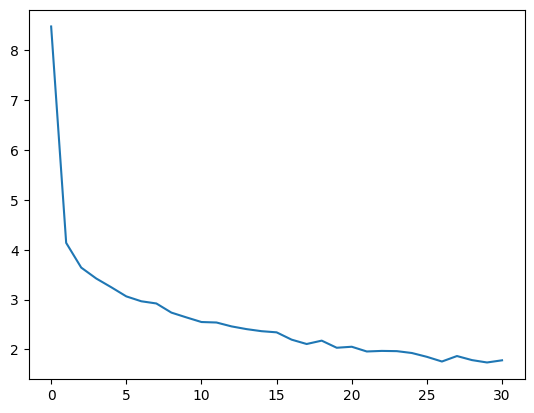

In [28]:
import matplotlib.pyplot as plt



plt.plot(losses)

In [1]:
x.shape[-1]

NameError: name 'x' is not defined

In [ ]:
x = torch.ten
gpt(x)

NameError: name 'x' is not defined